# Ranking 实验结果可视化与表格生成
此脚本会自动读取 `ranking/` 文件夹下的所有 JSON 结果文件，计算均值，并生成对比表格。

================ 文件: exp_ranking_200_t1_p20_pc_03_rho_13.json ================
### t1 噪声下的性能对比 (Ranking, N=200)
| Method | RMSE | MAE | Pairwise_Correlation | Kendall_Correlation | Pearson_Correlation | Time (s) |
|---|---|---|---|---|---|---|
| Pooled | 0.5997 | 0.0649 | 74.85% | 0.0000 | 0.0000 | 886.57 |
| Local | 0.9398 | 0.1695 | 72.36% | 0.0000 | 0.0000 | 0.00 |
| Avg | 0.4477 | 0.0816 | 75.80% | 0.0000 | 0.0000 | 0.00 |
| D-subGD | 0.5057 | 0.0891 | 75.64% | 0.0000 | 0.0000 | 51.47 |
| U-ADMM | 0.7829 | 0.0808 | 73.70% | 0.0000 | 0.0000 | 20.24 |




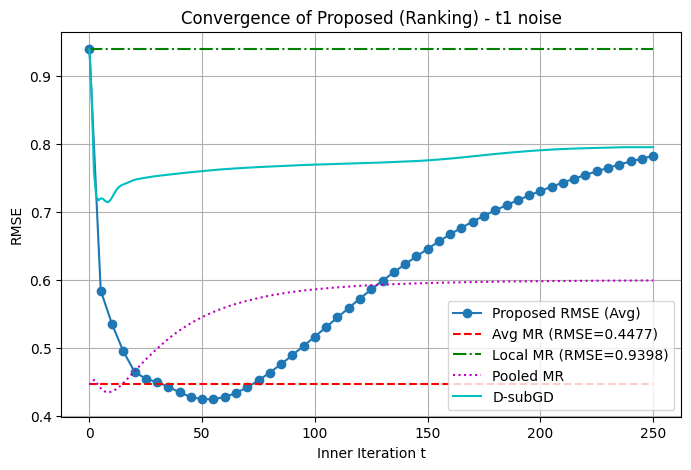

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
import glob
import os
from models.ranking import generate_ranking_data

# 寻找所有的 ranking 结果文件
# 适配新格式: {noise_type}_m{m}_n{n}_p{p}_pc{pc}_rho{rho}.json
files = glob.glob('ranking/*.json')
if not files:
    print("在 ranking/ 文件夹下没有找到 JSON 文件。请先运行 exp1_run_parallel_ranking.ipynb")

for filename in files:
    with open(filename, 'r', encoding='utf-8') as f:
        data = json.load(f)
    res = data['results']
    params = data['parameters']
    N = len(res)
    
    print(f"================ 文件: {os.path.basename(filename)} ================")
    md_table = f"### {params.get('noise_type', 'normal')} 噪声下的性能对比 (Ranking, N={N})\n"
    md_table += "| Method | RMSE | MAE | Pairwise_Acc | Time (s) |\n"
    md_table += "|---|---|---|---|---|\n"
    
    methods = ['Global', 'Local', 'Avg', 'D-subGD', 'D-ProxGD', 'U-ADMM']
    
    avg_hist = None
    for method in methods:
        if method in res[0]:
            rmses = [r[method]['RMSE'] for r in res if 'RMSE' in r[method]]
            maes = [r[method]['MAE'] for r in res if 'MAE' in r[method]]
            accs = [r[method].get('Pairwise_Correlation', 0.0) for r in res]
            times = [r[method]['Time'] for r in res]
            
            mean_rmse = np.mean(rmses)
            mean_mae = np.mean(maes)
            mean_acc = np.mean(accs)
            mean_time = np.mean(times)
            
            md_table += f"| {method} | {mean_rmse:.4f} | {mean_mae:.4f} | {mean_acc:.2%} | {mean_time:.2f} |\n"
            
            if method == 'U-ADMM' and 'hist_rmse' in res[0]['U-ADMM']:
                avg_hist = np.mean([r['U-ADMM']['hist_rmse'] for r in res], axis=0)
    
    print(md_table)
    
    # --- 新增：散点图绘制逻辑 ---
    print("\n[绘图] 正在生成预测散点图 (利用第一次运行的结果)...")
    test_seed = params.get('rng_seed', 42) + 999 
    d_test = generate_ranking_data(
        m=params['m'], n=params['n'], p_prime=params['p_prime'], 
        p=params['p'], pc=params['pc'], noise_type=params['noise_type'], 
        rng_seed=test_seed, noise_scale=params.get('noise_scale', 1.0)
    )
    X_test = d_test['X']
    theta_true = d_test['theta_true']
    true_scores = X_test @ theta_true
    
    plt.figure(figsize=(8, 6))
    # 美化颜色
    colors = {'U-ADMM': '#3498DB', 'D-subGD': '#E67E22', 'Local': '#2ECC71', 'Avg': '#E74C3C'}
    markers = {'U-ADMM': 'o', 'D-subGD': 'x', 'Local': '^', 'Avg': 's'}
    
    res_one = res[0] 
    for m_key in ['U-ADMM', 'D-subGD', 'Local', 'Avg']:
        if m_key in res_one and 'theta_hat' in res_one[m_key]:
            theta_hat = np.array(res_one[m_key]['theta_hat']).reshape(-1, 1)
            pred_scores = X_test @ theta_hat
            label_name = 'Proposed (U-ADMM)' if m_key == 'U-ADMM' else m_key
            plt.scatter(true_scores.flatten(), pred_scores.flatten(), 
                        alpha=0.6, label=label_name, 
                        color=colors.get(m_key), marker=markers.get(m_key))
            
    lims = [np.min(true_scores), np.max(true_scores)]
    plt.plot(lims, lims, 'k--', alpha=0.5, label='Ideal y=x')
    plt.xlabel('True Latent Scores')
    plt.ylabel('Predicted Scores')
    plt.title(f"Prediction Scores: Magnitude Bias (m={params['m']}, n={params['n']}, p={params['p']})")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    # --- 收敛曲线 ---
    if avg_hist is not None:
        plt.figure(figsize=(7, 4))
        x_axis = np.arange(len(avg_hist)) * params['W_inner']
        plt.plot(x_axis, avg_hist, marker='o', label='U-ADMM RMSE')
        plt.xlabel('Iter')
        plt.ylabel('RMSE')
        plt.title('Convergence Trajectory')
        plt.grid(True)
        plt.legend()
        plt.show()
